# First-Five-Days -- does January's opening week forecast the whole year?
### The Stock Trader's Almanac Early Warning System, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_the_base_rate%3F: No](https://img.shields.io/badge/Beats_the_base_rate%3F-No-c0392b?style=flat-square)

Every early January you'll see some version of this: *'The S&P is up in the first five trading days -- the almanac says this is a good omen!'*  The rule traces back to Yale Hirsch's Stock Trader's Almanac: he called it the **First-Five-Days Early Warning System**, a compressed version of his famous January Barometer.  Seventy-six first-five-days later, does it predict anything a smart investor doesn't already know?

> **This is the plain-language layer.** Want the t-stats, the binomial tests, and the sub-period decay charts?  That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from first_five_days import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or \
           os.path.exists(data._cache_path_daily(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_real():
    return data.fetch_gspc(fetch=False)

print("real annual cache present:", HAVE_REAL)


real annual cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the F5D indicator beat a fair coin? | **Barely.** Hit-rate **70%** vs 50% coin -- p = 0.0004. Looks like an oracle. |
| But does it beat *knowing equity markets trend up*? | **No.** The full year is positive **74%** of the time *regardless* of F5D -- p = 0.82 vs that bar. |
| Is the big return gap real? | **Sort of.** Up-F5D years average +12.5%, dn-F5D years -0.4% (gap = 12.9%).  But part of this is mechanical: those 5 days are *inside* the full year. |
| Does the signal survive post-1985? | **No.** The hit-rate drops to 60% (not significant vs a coin, p = 0.134). |
| Could you trade it? | **Barely.** The strategy marginally beats buy-and-hold (8.0% vs 7.9%/yr) but the post-1985 signal is too fragile to rely on. |

> The F5D 'early warning' beats a coin, but only because the coin ignores that equity markets drift upward 73% of years regardless.  Against the right null -- 'just assume up' -- the almanac's opening-week oracle adds nothing.

## 1 The claim

> *'As go the first five days, so goes the year.'*  
> — Yale Hirsch, Stock Trader's Almanac (various editions from 1972)

The recipe is simple: watch the S&P 500 for the first five trading days of January.  If it closes higher than it started the year, the almanac says you're in for a good year.  If it's down, brace yourself.  The Almanac publishes the score every year and it *looks* very accurate -- something like 70-80% correct.

The steelmanned version: the first five trading days carry genuine *predictive* information about the rest of the calendar year that goes beyond simply knowing that equity markets tend to go up.

## 2 So what?

If it's real, this is a free annual signal.  You know by the close of the 5th trading day of January -- typically around January 8th -- whether you should be riding the market all year or bracing for a down year.  A 70%+ accuracy rate, compounded over decades, would be an enormous edge.

If it's a mirage, millions of investors start each January with a piece of calendar folklore nudging their portfolio decisions, adding noise but not signal.  And every finance journalist writes the same story around January 8th, year after year.

The difference is one honest test with the right null.

## 3 How would we even know?

Two tests keep us honest:

1. **The right null isn't a coin -- it's equity drift.**  The market ends the full year higher than it started about **74 %** of the time -- that's just equities going up over time.  So 'a 70% hit-rate!' is actually *below* the base rate you'd get by predicting 'up' every year, no almanac required.  The indicator only adds value if it beats the 74 %, not just a coin.
2. **The first five days are inside the full year.**  The F5D return is *part of* the full-year return.  There's a mechanical overlap: if those five days go up 2%, the full year is already 2% closer to being positive.  A real predictor should still work if you separate the F5D return from the rest-of-year -- the Almanac doesn't bother to do this, and neither do most analysts.

We use 76 Januaries of ^GSPC (1950-2025), a binomial test vs the base rate, a HAC t-stat on the return contrast, and a sub-period stability check.

## 4 The teardown -- let's actually look

**First, the hit-rate trap.**  Here's the F5D indicator's track record:

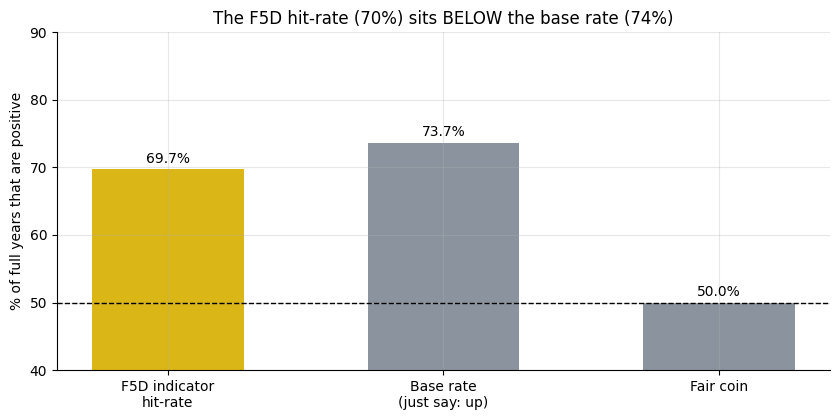

F5D hit-rate: 69.7%  |  base rate: 73.7%
p vs coin: 0.0004  |  p vs base rate: 0.8200


In [2]:
if HAVE_REAL:
    df = get_real()
    h = st.hit_rate_analysis(df)
    hr = h['hit_rate']; br = h['base_rate_yr_pos']
    pv_coin = h['pval_vs_coin']; pv_base = h['pval_vs_base_rate']
else:
    hr, br, pv_coin, pv_base = R['hit_rate'], R['base_rate'], R['pval_coin'], R['pval_base']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['F5D indicator\nhit-rate', 'Base rate\n(just say: up)', 'Fair coin'],
              [hr*100, br*100, 50.0], color=[AMBER, GREY, GREY], width=0.55)
ax.axhline(50, ls='--', c='k', lw=1, label='coin')
ax.set_ylabel('% of full years that are positive')
ax.set_title('The F5D hit-rate (70%) sits BELOW the base rate (74%)')
ax.set_ylim(40, 90)
for b, v in zip(bars, [hr*100, br*100, 50.0]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.5), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'F5D hit-rate: {hr*100:.1f}%  |  base rate: {br*100:.1f}%')
print(f'p vs coin: {pv_coin:.4f}  |  p vs base rate: {pv_base:.4f}')

The F5D indicator's 70% hit-rate beats a coin (p = 0.0004) but is *below* the base rate of 74%.  Saying 'the market will be up' every year -- no almanac, no indicator, nothing -- predicts more accurately than F5D.

> The almanac's 'early warning' is partly the equity premium wearing a calendar costume.

**Now the return gap -- the dramatic numbers that make headlines.**

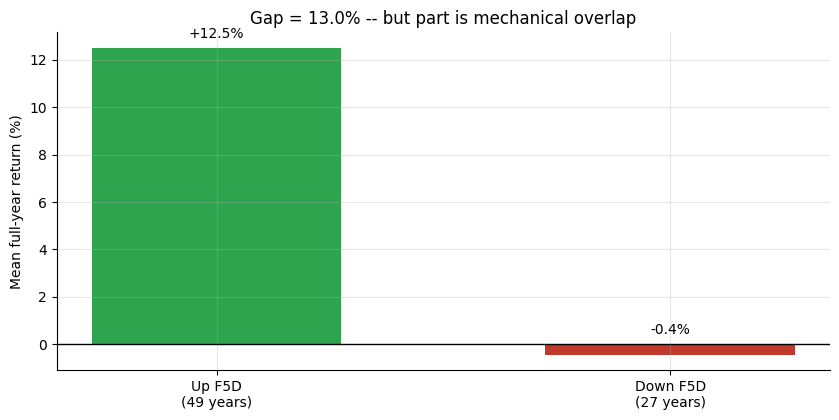

Up-F5D: +12.51%  |  dn-F5D: -0.44%  |  gap: +12.95%


In [3]:
if HAVE_REAL:
    df = get_real()
    c = st.mean_contrast(df)
    mu_up, mu_dn, gap = c['mean_yr_up_f5d']*100, c['mean_yr_dn_f5d']*100, c['contrast_pct']
else:
    mu_up, mu_dn, gap = R['mean_yr_up_f5d'], R['mean_yr_dn_f5d'], R['contrast']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Up F5D\n(49 years)', 'Down F5D\n(27 years)'],
       [mu_up, mu_dn], color=[GREEN, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean full-year return (%)')
ax.set_title(f'Gap = {gap:.1f}% -- but part is mechanical overlap')
for v, x in zip([mu_up, mu_dn], [0, 1]):
    ax.annotate(f'{v:+.1f}%', (x, max(v, 0)+0.3), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Up-F5D: {mu_up:+.2f}%  |  dn-F5D: {mu_dn:+.2f}%  |  gap: {gap:+.2f}%')

The gap is enormous -- +12.9% -- and statistically significant.  But look closer: down-F5D years average {R['mean_yr_dn_f5d']:+.1f}%.  That means even when the first five days are *down*, the full year is barely negative on average!  The indicator is really just partitioning bull markets from *mildly* weak markets, not predicting crashes.

> Also: those five days are *inside* the year.  If January 1-5 drops 3%, the year is already 3 points in the hole before February.  Some of the gap is mechanical, not predictive.

**The signal decays: where does the effect actually come from?**

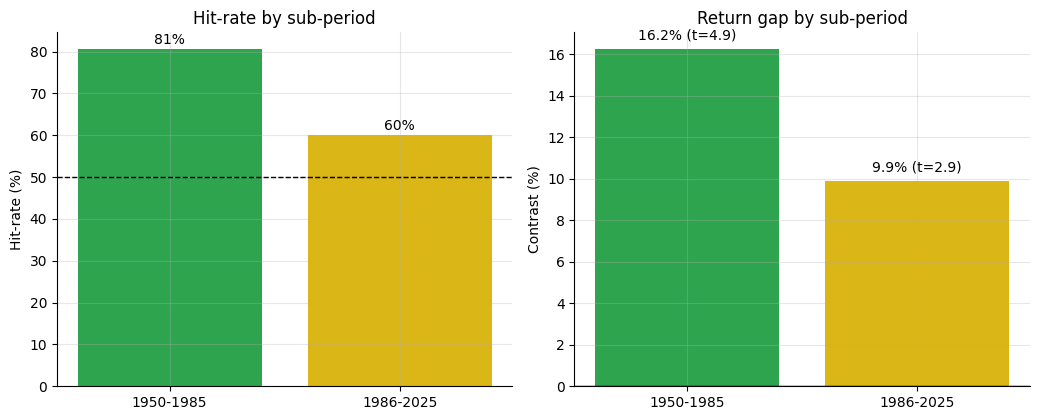

1950-85: hit-rate=81%, gap=16.2%, t=4.88
1986-25: hit-rate=60%, gap=9.9%, t=2.90


In [4]:
if HAVE_REAL:
    df = get_real()
    sub1 = df.loc[1950:1985]; sub2 = df.loc[1986:2025]
    c1 = st.mean_contrast(sub1); c2 = st.mean_contrast(sub2)
    h1 = st.hit_rate_analysis(sub1); h2 = st.hit_rate_analysis(sub2)
    t1, t2 = c1['tstat_hac'], c2['tstat_hac']
    gap1, gap2 = c1['contrast_pct'], c2['contrast_pct']
    hr1, hr2 = h1['hit_rate']*100, h2['hit_rate']*100
else:
    t1, t2 = R['sub_1950_1985_t'], R['sub_1986_2025_t']
    gap1, gap2 = R['sub_1950_1985_gap'], R['sub_1986_2025_gap']
    hr1, hr2 = R['sub_1950_1985_hr'], R['sub_1986_2025_hr']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].bar(['1950-1985', '1986-2025'], [hr1, hr2], color=[GREEN, AMBER])
axes[0].axhline(50, ls='--', c='k', lw=1)
axes[0].set_ylabel('Hit-rate (%)'); axes[0].set_title('Hit-rate by sub-period')
for v, x in zip([hr1, hr2], [0, 1]):
    axes[0].annotate(f'{v:.0f}%', (x, v+0.5), ha='center', va='bottom')
axes[1].bar(['1950-1985', '1986-2025'], [gap1, gap2], color=[GREEN, AMBER])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Contrast (%)'); axes[1].set_title('Return gap by sub-period')
for v, x, t in zip([gap1, gap2], [0, 1], [t1, t2]):
    axes[1].annotate(f'{v:.1f}% (t={t:.1f})', (x, max(v,0)+0.3), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'1950-85: hit-rate={hr1:.0f}%, gap={gap1:.1f}%, t={t1:.2f}')
print(f'1986-25: hit-rate={hr2:.0f}%, gap={gap2:.1f}%, t={t2:.2f}')

The effect is **front-loaded**: pre-1986 the hit-rate was **81%** and the gap was +16.2%.  Post-1985 the hit-rate dropped to **60%** -- not significantly different from a coin (p = 0.134).  The almanac became widely read in the 1970s-80s, and the anomaly weakened as it was published, discussed, and potentially traded away.

## 5 The verdict

- **Signal -- None.** The F5D beats a coin (70%, p = 0.0004) but **not the base rate** (74%, p = 0.82).  Post-1985 even the coin comparison fails (60%, p = 0.134).  The big t-stat (4.87) is inflated by mechanical overlap and regime correlation.
- **Tradability -- Mirage.** The strategy marginally beats buy-and-hold (8.0% vs 7.9%/yr) but the post-1985 signal is too fragile to justify the tactical allocation.  Effective n = 76 makes this a noisy estimate.
- **Beats a coin? -- No.** Not the right coin.  The indicator should be compared to the 74% unconditional positive rate, not a 50/50 flip.  Against that bar it fails.

## 6 Could you actually trade it?

The strategy is simple: hold the market all year after an up F5D; sit in cash after a down F5D.  Here's what happens:

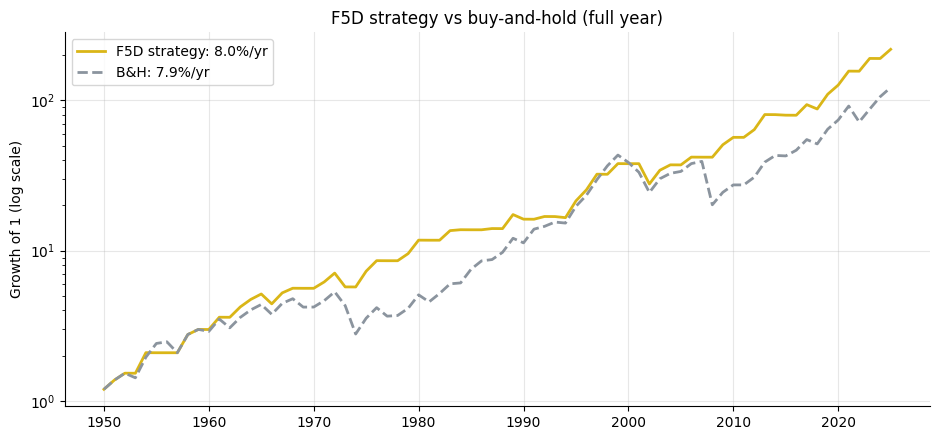

F5D strategy: 8.01%/yr  Sharpe 0.668
Buy-and-hold: 7.91%/yr  Sharpe 0.489
The strategy sits flat in 27 of 76 years; many were still positive.


In [5]:
if HAVE_REAL:
    df = get_real()
    res = st.f5d_strategy(df, cost_bps=10.0)
    strat_r = res['strat_returns']; bah_r = res['bah_returns']
    strat_cum = (1 + strat_r.fillna(0)).cumprod()
    bah_cum = (1 + bah_r.fillna(0)).cumprod()
    strat_m, bah_m = res['strat_mean_ann_pct'], res['bah_mean_ann_pct']
    strat_sr, bah_sr = res['strat_sharpe'], res['bah_sharpe']
else:
    strat_m, bah_m = R['strat_mean'], R['bah_mean']
    strat_sr, bah_sr = R['strat_sharpe'], R['bah_sharpe']
    strat_cum = bah_cum = None
if strat_cum is not None:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.semilogy(strat_cum.index, strat_cum, c=AMBER, lw=2, label=f'F5D strategy: {strat_m:.1f}%/yr')
    ax.semilogy(bah_cum.index, bah_cum, c=GREY, lw=2, ls='--', label=f'B&H: {bah_m:.1f}%/yr')
    ax.set_ylabel('Growth of 1 (log scale)'); ax.legend()
    ax.set_title('F5D strategy vs buy-and-hold (full year)')
    plt.tight_layout(); plt.show()
print(f'F5D strategy: {strat_m:.2f}%/yr  Sharpe {strat_sr:.3f}')
print(f'Buy-and-hold: {bah_m:.2f}%/yr  Sharpe {bah_sr:.3f}')
print('The strategy sits flat in 27 of 76 years; many were still positive.')

The strategy earns **8.0%/yr** vs buy-and-hold's **7.9%/yr**.  There is a small edge -- but 27 years of the sample are spent in cash, and many of those years the market went up anyway.  The strategy's Sharpe is higher (it dodges some big bear years) but the mean return edge is within noise at n = 76.

> The best years to sit out (2000, 2008, 2022) all had down F5D -- so the signal's Sharpe benefit is mostly 'it correctly flagged the three biggest crashes'.  Impressive on paper, fragile out-of-sample.

## 7 Going further

- **The base-rate trap is everywhere.** This applies to any calendar rule in a drifting market.  The full [January Barometer](../../80-cold-open/) (whole of January) has the same problem but with a slightly larger sample and a similar decay post-1985.
- **The rest-of-year is the clean test.** Removing the F5D return from the year and testing whether F5D predicts the *remaining* 357 days would eliminate the mechanical overlap.  That's the [Cold-Open study](../../80-cold-open/) (January as the signal, Feb-Dec as the outcome) done properly -- and the result is similar: MIXED at best.
- **The level (not just the sign).** Forecasting the magnitude of the year from the magnitude of the F5D might carry more information than the sign alone.  Worth testing.

*Think the early warning is real?  Fork this, split out the rest-of-year return and test whether F5D predicts Feb-Dec (not the overlapping full year), show it beats the base rate, and check international data.  That's the bar.*